In [19]:
import os
import json
import pandas as pd
from os.path import join
import matplotlib.pyplot as plt
from pprint import pprint
import seaborn as sns

In [20]:
def get_dataset_name(dataset_id, nnUNet_raw="data/nnUNet_raw"):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [dataset_name for dataset_name in os.listdir(nnUNet_raw) if dataset_name.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, dataset_name))]
    assert len(dataset_name) == 1, f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1"
    return dataset_name[0]

def extract_params(model_dir):
    metrics_file = f"{model_dir}/model_analysis.json"
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['parameters']['total']

def get_results(model_dir, split="val", fold=0):
    if split == "val":
        metrics_file = f"{model_dir}/fold_{fold}/validation/summary.json"
    else:
        raise ValueError(f"Not implemented for split {split}")
    
    with open(metrics_file, 'r') as f:
        metrics = json.load(f)
    return metrics['foreground_mean']

In [11]:
def get_baseline_results_from_log(model_dir):
    log_path = f"{model_dir}/fold_0/log.csv"
    df = pd.read_csv(log_path)
    dice = df['val_dice'].iloc[-1]
    return dice

def get_baseline_results_csv(model_dir, dataset_name):
    log_path = f"{model_dir}/fold_0/test/results.csv"
    df = pd.read_csv(log_path)
    dice = df[df['test_dataset_name'] == dataset_name]['dice'].values[0]
    return dice / 100


def get_baseline_results(dataset_id, models=["TinyUNet", "CMUNeXt", "UNeXt"], results_dir="data/nnUNet_results"):
    cfg = "2d"
    dataset_name = get_dataset_name(dataset_id)
        
    results = {model: {'dice': None, 'params': None} for model in models}
    for model in models:
        if model == "TinyUNet":
            trainer = "TinyUNetTrainer"
            model_dir = f"/home/ultrai/UltrAi/UNeXt/models/{model}/{dataset_name}"
        elif model == "CMUNeXt":
            trainer = "CMUNeXtTrainer"
            model_dir = f"/home/ultrai/UltrAi/CMUNeXt/models/CMUNeXt-S/{dataset_name}"
        elif model == "UNeXt":
            # dataset_id = 303
            # dataset_name = get_dataset_name(dataset_id)
            trainer = "UNeXtTrainer_100epochs"
            model_dir = f"/home/ultrai/UltrAi/UNeXt/models/UNext/{dataset_name}"
        else:
            raise ValueError(f"Unknown model: {model}. Please choose from {', '.join(models)}")

        params = extract_params(model_dir)
        # dice = get_results(model_dir, split=split, fold=fold)['Dice']
        if model == "CMUNeXt":
            dice = get_baseline_results_csv(model_dir, dataset_name)
        else:
            dice = get_baseline_results_from_log(model_dir)
        results[model]['dice'] = round(dice * 100, 2)
        results[model]['params'] = params
    return results


def get_metric(cfg, dataset_name, metric="naswot", naswot_dir="results/naswot", encoder_only=False, batches=100):
    if encoder_only:
        naswot_csv = join(naswot_dir, f"{dataset_name}_metrics_encoder_only_b{batches}.csv")
    else:
        naswot_csv = join(naswot_dir, f"{dataset_name}_metrics_b{batches}.csv")
    if not os.path.exists(naswot_csv):
        return None
    df = pd.read_csv(naswot_csv)
    if df.empty or "cfg" not in df.columns:
        return None
    df = df[df['cfg'] == cfg]
    if df.empty:
        return None
    nas_metric = df[metric].iloc[-1]
    # if metric == "jacobian":
    #     nas_metric = - nas_metric
    return nas_metric


In [22]:
trainer = "nnUNetTrainer_100epochs"
plans = "nnUNetPlans"
results_dir = "data/nnUNet_results"
model = "nnunet"
fold = 0
split = "val"

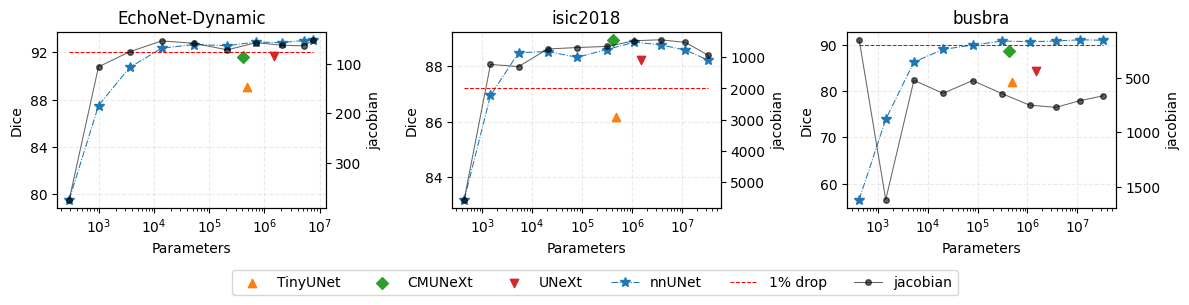

In [33]:
cfgs = [
    "2d_tiny1",
    "2d_tiny2",
    "2d_tiny4",
    "2d_tiny8",
    "2d_tiny16",
    "2d_tiny32",
    "2d_tiny64",
    "2d_tiny128",
    "2d_tiny256",
    "2d",
]

baselines = [
    "TinyUNet",
    "CMUNeXt",
    "UNeXt"
]

dataset_ids = [
    302,
    300,
    301,
]

save_dir = "results"
os.makedirs(save_dir, exist_ok=True)

# NASWOT settings
batches = 4
encoder_only = False
# metric = "naswot"
# metric = "synflow"
# metric = "gradnorm"
# metric = "snip"
# metric = "fisher"
metric = "jacobian"

# fig = plt.figure(figsize=(8.5, 2.65))
# fig = plt.figure(figsize=(8.5, 3))
fig = plt.figure(figsize=(12, 3))
for i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)
    params_list = []
    dice_list = []
    nas_metric_list = []

    for cfg in cfgs:
        # if dataset_id == 301 and cfg == "2d_tiny1":
        #     continue
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        params = extract_params(model_dir)
        dice = get_results(model_dir, split=split, fold=fold)['Dice']
        nas_metric = get_metric(cfg, dataset_name, metric=metric, encoder_only=encoder_only, batches=batches)
        dice = dice * 100
        # print(f"{cfg}: {params}: {dice:.2f}%")
        params_list.append(params)
        dice_list.append(dice)
        nas_metric_list.append(nas_metric)
    
    
    plt.subplot(1, len(dataset_ids), i + 1)
    ax = plt.gca()

    baseline_results = get_baseline_results(dataset_id, models=baselines, results_dir=results_dir)
    # colors = sns.color_palette("Blues", n_colors=len(baselines), desat=0.7) #[:-1] + [sns.color_palette("Reds", n_colors=2)[-1]]
    colors = sns.color_palette(n_colors=len(baselines) + 1)
    markers = ['^', 'D', 'v', 'X', '^', '<', '>', 'p', 'h', 'H', '8', '1']
    for b, baseline_model in enumerate(baselines):
        dice = baseline_results[baseline_model]['dice']
        params = baseline_results[baseline_model]['params']
        label = baseline_model if i == 0 else "_nolegend_"
        ax.scatter(params, dice, label=label, color=colors[b+1], marker=markers[b])
    
    label = "nnUNet" if i == 0 else "_nolegend_"
    ax.plot(params_list, dice_list, marker='*', linestyle='dashdot', linewidth=0.75, markersize=7, color=colors[0], label=label)
    ax2 = ax.twinx()
    import numpy as np
    naswot_metrics = [np.nan if n is None else n for n in nas_metric_list]
    naswot_label = f'{metric}' if i == 0 else '_nolegend_'
    ax2.plot(params_list, naswot_metrics, marker='o', linestyle='-', linewidth=0.75, markersize=4, color='black', alpha=0.6, label=naswot_label)
    if metric == "jacobian":
        ax2.invert_yaxis()
    ax2.set_ylabel(f'{metric}')
    drop_label = "1% drop" if i == 0 else "_nolegend_"
    ax.hlines(dice_list[-1]-1, params_list[0], params_list[-1], colors='red', linestyles='dashed', linewidth=0.75, label=drop_label)
    ax.set_xlabel('Parameters')
    ax.set_ylabel('Dice')
    ax.set_title(f'{dataset_name.split("_")[1]}')
    ax.set_xscale('log')
    if dataset_id == 301:
        ax.yaxis.set_major_locator(plt.MultipleLocator(10))
    elif dataset_id == 302:
        ax.yaxis.set_major_locator(plt.MultipleLocator(4))
    else:
        ax.yaxis.set_major_locator(plt.MultipleLocator(2))

    # plt.ylim(82, 95)
    ax.grid(True, alpha=0.25, linestyle='--')

# ONE figure-level legend (labels only come from the first subplot)
fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.025), ncol=6)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(f'{save_dir}/dice_vs_params.png', dpi=300, bbox_inches='tight')
plt.show()


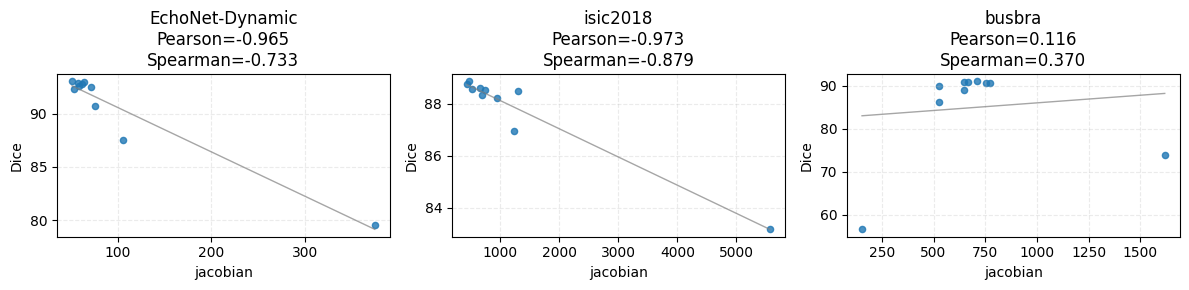

                      dataset   n   pearson  spearman
0  Dataset302_EchoNet-Dynamic  10 -0.964576 -0.733333
1         Dataset300_isic2018  10 -0.973208 -0.878788
2           Dataset301_busbra  10  0.115961  0.369697


In [34]:
# Correlation analysis (Dice vs metric)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

corr_rows = []
fig = plt.figure(figsize=(12, 3))

for i, dataset_id in enumerate(dataset_ids):
    dataset_name = get_dataset_name(dataset_id)
    dice_list = []
    metric_list = []

    for cfg in cfgs:
        # skip second config for busbra (outlier)
        model_dir = f"{results_dir}/{model}/{dataset_name}/{trainer}__{plans}__{cfg}"
        try:
            dice = get_results(model_dir, split=split, fold=fold)['Dice'] * 100
        except Exception:
            continue
        m = get_metric(cfg, dataset_name, metric=metric, encoder_only=encoder_only, batches=batches)
        if m is None:
            continue
        dice_list.append(dice)
        metric_list.append(m)

    if len(dice_list) < 2:
        corr_rows.append({"dataset": dataset_name, "n": len(dice_list), "pearson": np.nan, "spearman": np.nan})
        continue

    s = pd.Series(dice_list)
    m = pd.Series(metric_list)
    pearson = s.corr(m, method='pearson')
    spearman = s.corr(m, method='spearman')
    corr_rows.append({"dataset": dataset_name, "n": len(s), "pearson": pearson, "spearman": spearman})

    plt.subplot(1, len(dataset_ids), i + 1)
    ax = plt.gca()
    ax.scatter(m, s, s=20, alpha=0.8)
    if len(m) >= 2:
        coef = np.polyfit(m, s, 1)
        xfit = np.linspace(m.min(), m.max(), 100)
        yfit = coef[0] * xfit + coef[1]
        ax.plot(xfit, yfit, color="gray", linewidth=1, alpha=0.7)
    ax.set_xlabel(metric)
    ax.set_ylabel("Dice")
    ax.set_title(f"{dataset_name.split("_")[1]}\nPearson={pearson:.3f}\nSpearman={spearman:.3f}")
    ax.grid(True, alpha=0.25, linestyle="--")

plt.tight_layout()
plt.savefig(f"{save_dir}/{metric}_corr_vs_dice.png", dpi=300, bbox_inches='tight')
plt.show()

corr_df = pd.DataFrame(corr_rows)
print(corr_df)
